#### Original loop

In [1]:
 #for each sigma in [.01,.05,.10,.20,.30], multiply by 256, could be 4 and 30 for now
    # for image in images (by images we mean frame variable as defined below, should be 90 constant frames, each image has 90 frames)
        # for each noise each time we add noise (implement with another for loop, we need 1000 iterations(at first do 100, 200)), 
            #    make sure in range (0,256)
            # for each scan
                # collect prediction output
                # concat. outputs for different scans
            # concat response outputs, collect shape
            # shape should be (1000, 90, number neurons) (call this response_shape), where 90 is number of frames (could be 15 30 etc)
        # concat all the response_shape objects together, shape will be (number of images, 1000, 90, num neurons)
        # calc. sum spike count over 90, shape should be (number images, 1000, number neurons)
        
        # calc. mean over 1000, shape should be (number images, number neurons)
        # calc. var over 1000, shape should be (number images, number neurons)
        # plot mean vs var
        # calc. fano factor var over mean
        # plot fano factor dist. as histogram

#### Environment

In [5]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson


#### pre-defined functions

In [6]:
def visual_prediction(session, scan_idx, stimuli_noise):
    pred_model, table = scan(session, scan_idx, directory = os.path.join(os.getcwd(), "data","microns")) # look at data/microns/scans.csv for numbers that work
    results = pred_model.predict(stimuli = stimuli_noise)
    results = np.array(results) # should be array regardless
    return results

def generate_noise(noise_type, num_frames, sigma, mean = 0):
    if noise_type == "constant":
        constant_noise_array = np.empty((num_frames, 144, 256))
        
        noise = np.random.normal(loc = mean, scale = sigma, size = (144,256))
        constant_noise = np.stack([constant_noise_array.copy() for i in range(num_frames)], axis = 0)
        return constant_noise
    
    elif noise_type == "dynamic": return np.random.normal(loc = mean, scale = sigma, size = (num_frames, 144, 256))
    elif noise_type == "no noise": return np.zeros(shape = (num_frames, 144, 256))
    else: print("\n---Noise input not recognized, please try again---")

#### meeting with anton, july 1

- fix code
    - eliminate mean as parameter, will always be 0
- for future ref., output from for loop should include brain region
- send same 30 neurons, each for sigma 3 15 30 
    - dynamic and constant
- send histograms of responses
- plot LR and smoothing curve
- annotate plots with CI and slope of LR
- later send plots of fano factor as well
- if can't find neuron id's within a few hours then reach out to ralf/anton

plots (overarching goal is we want to characterize by brain area, for now remind ralf that we are looking at a mix)
- histograms of individual neurons responses for an image with varying noise, illustrates variability in response created by input noise
- scatter plot of var mean relationship, includes all neurons and all images
    - mean is average response of a neuron to same image with varying noise 
- fano factor histogram, for a real neuron ff around 1 and we want to see how artifical neurons differ
    - pick sigma value with ff closest to 1
- pseudo poisson parameters histograms, two plots (one each), illustrates pseudo poisson dist. and how it is different from poisson

#### july 1

NOTE: say on plots that these histograms DO NOT indicate which region of the brain the neuron is in

In [ ]:
import matplotlib.ticker as ticker
def plot_select30(array, title, neurons):
    neuron_pvalue = pd.DataFrame({

    }, columns = ['neuron', 'p-value'])
    fig, axes = plt.subplots(5,6, figsize = (20,6))

    p_values = np.empty((neurons.size))
    test_statistics = np.empty((neurons.size))

    for id, neuron in enumerate(neurons):
        row = id // 6
        col = id % 6
        ax = axes[row, col]
        plot = np.sum(array[:,:,neuron], axis = 1).flatten()
        ax.hist(plot)
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{round(x,3)}"))

        # hypothesis test
        p_value, test_statistic = shapiro(plot)
        p_values[id] = p_value
        test_statistics[id] = test_statistic

    
    fig.suptitle(f"Neuron outputs: {title}")
    fig.supxlabel('predicted firing rate')
    fig.supylabel('counts')
    plt.tight_layout()
    plt.show()

    print("For the following neurons: \n",neurons)
    print("Value counts for p > alpha of 0.05, which would indicate that the graphs do show a gaussian distribution.",np.unique(p_values > 0.05, return_counts = True))


#### new prediction loop

In [7]:
# noise_type can be "constant", "dynamic", or "no noise"
# image is a single image
# sigma is a single sigma
# ex. input would be predict_loop("dynamic", image1, 3)
def predict_loop(noise_type, noise_seeds, image, sigma):

# check here if input scans is 1d or 2d

# in order to minimize storage, pre allocate array sizes 
    num_neurons = 7493 # navigate to scans.csv and calculate
    num_frames = image.shape[0] 

        # results for each time we add noise
    noise_results = np.empty((noise_seeds, num_frames, num_neurons)) 

    for noise_i in range(noise_seeds):
                
        # need to generate new noise every iteration 
        
        new_noise = generate_noise(noise_type, num_frames, sigma)

        new_image = (image + new_noise).astype('uint8')

        sessions_scans = [[4,7]] # just one scan

        # make predictions for one noise seed
        for pair in sessions_scans:
            prediction1_std4 = visual_prediction(pair[0], pair[1], new_image) 
            try:
                final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
            except NameError:
                final_concat1_std4 = prediction1_std4

        noise_results[noise_i] = final_concat1_std4
        del final_concat1_std4
    noise_stack = np.stack(noise_results, axis = 0) # generate final object/stack of predictions after all noise seeds

    return noise_stack

In [8]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

In [9]:
dynamic3 = predict_loop("dynamic", 100, frames, 3)

100%|██████████| 222M/222M [00:17<00:00, 13.0MB/s] 


In [10]:
dynamic3.shape

(100, 15, 7493)

In [16]:
rand_neurons = np.random.randint(0,7493, size = 30)
type(rand_neurons)

numpy.ndarray

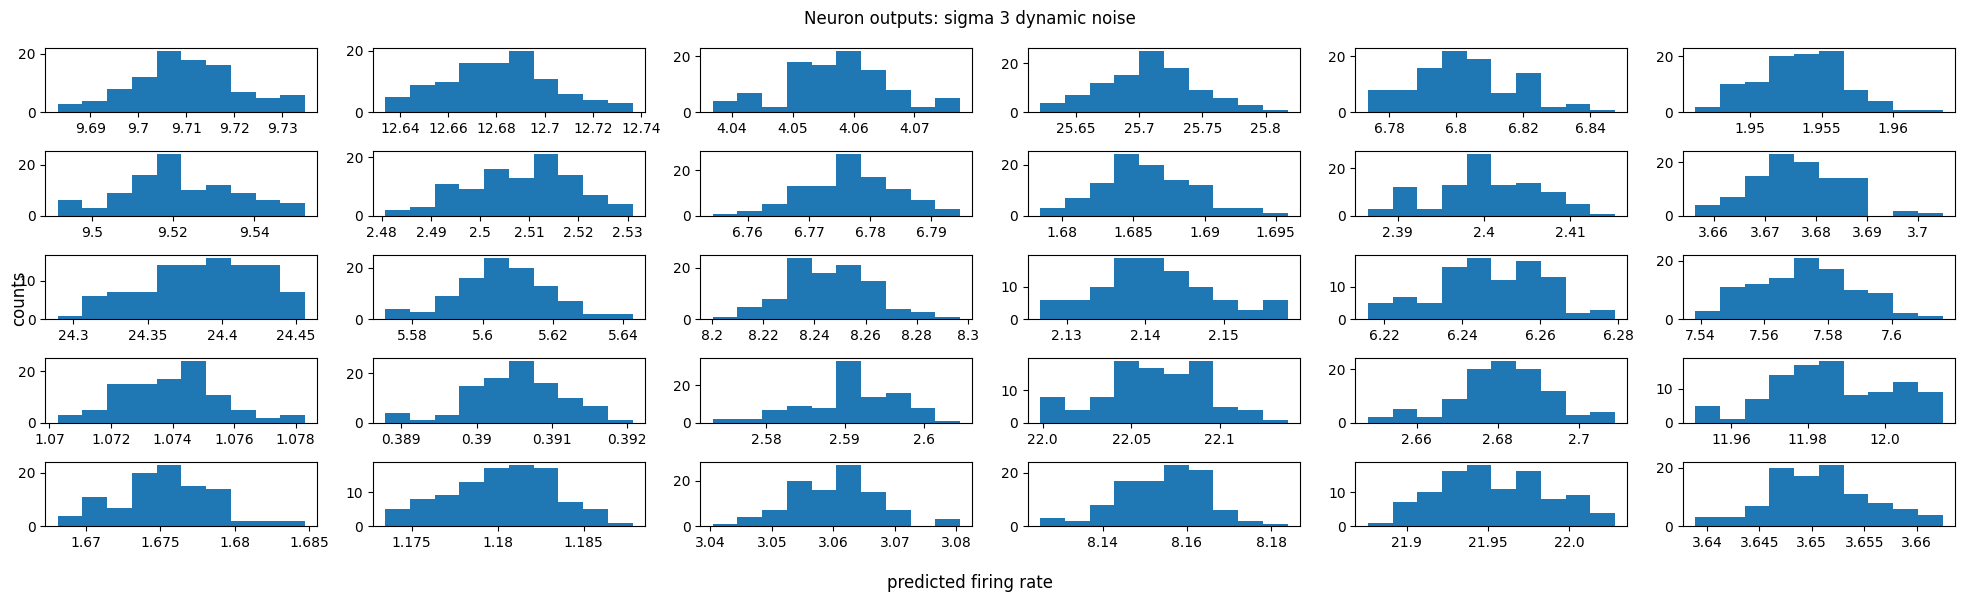

For the following neurons: 
 [5688  603 6035 6053 4126   11 5904 2788 3056 4610  127 6733 6346 1698
 6029 1392 5543 4781 7342  732 6288 2307 2952 4749 5667 7049 2157  522
 2759  619]
Value counts for p > alpha of 0.05, which would indicate that the graphs do show a gaussian distribution. (array([ True]), array([30]))


In [18]:
plot_select30(dynamic3, "sigma 3 dynamic noise", rand_neurons)

In [ ]:
dynamic15 = predict_loop("dynamic", 100, frames, 15)
dyanmic30 = predict_loop("dynamic", 100, frames, 30)

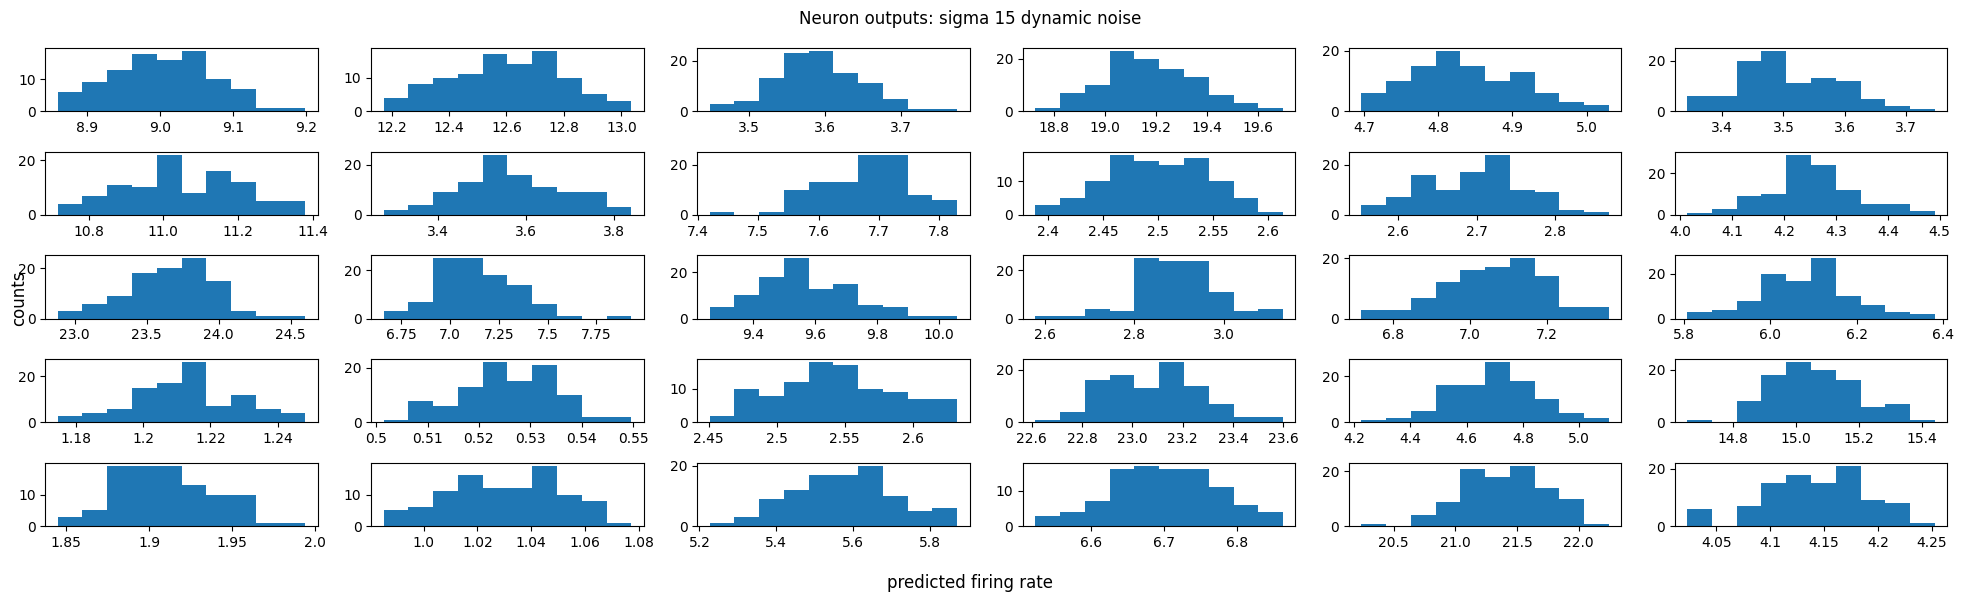

For the following neurons: 
 [5688  603 6035 6053 4126   11 5904 2788 3056 4610  127 6733 6346 1698
 6029 1392 5543 4781 7342  732 6288 2307 2952 4749 5667 7049 2157  522
 2759  619]
Value counts for p > alpha of 0.05, which would indicate that the graphs do show a gaussian distribution. (array([ True]), array([30]))


In [20]:
plot_select30(dynamic15, "sigma 15 dynamic noise", rand_neurons)

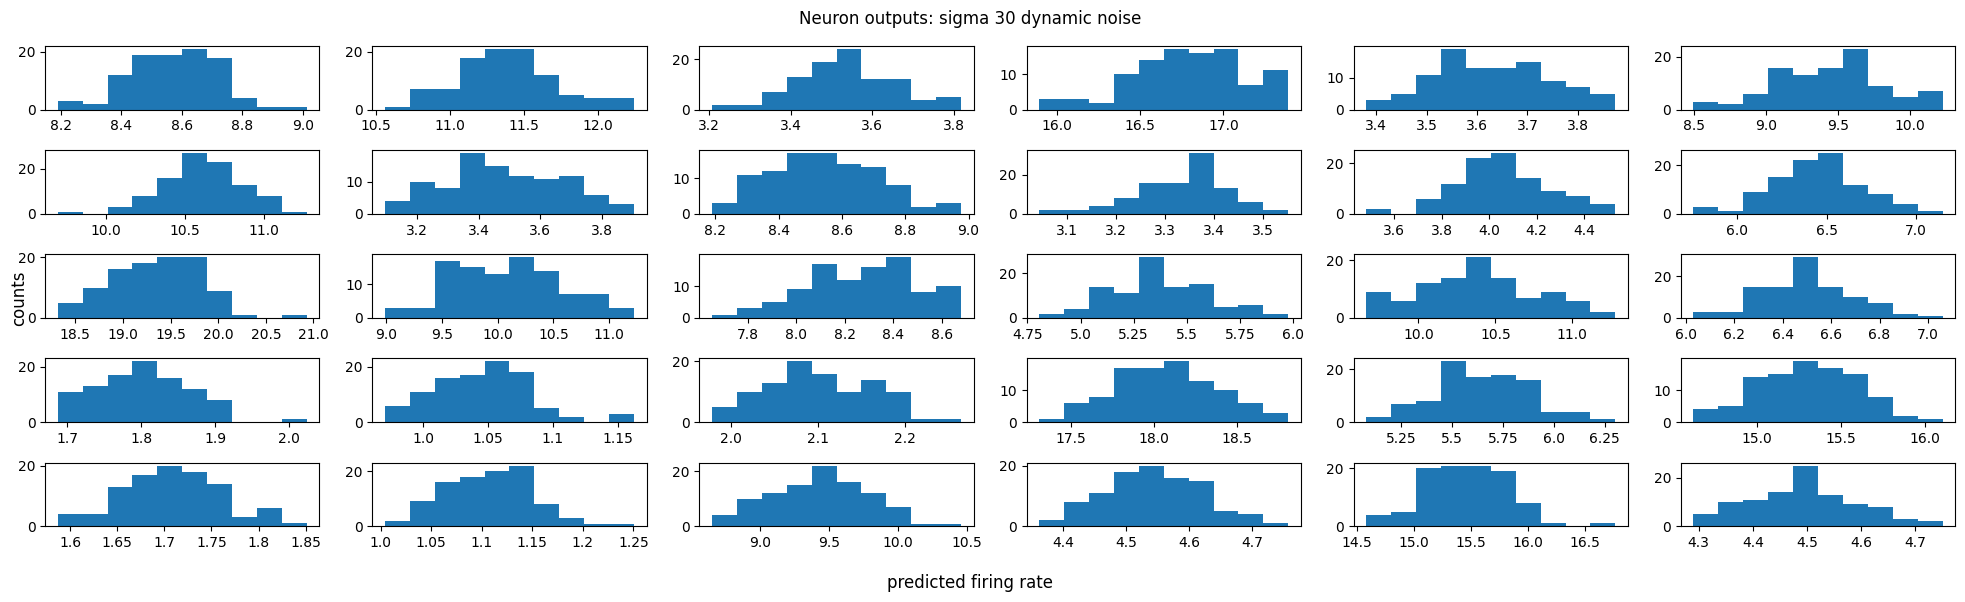

For the following neurons: 
 [5688  603 6035 6053 4126   11 5904 2788 3056 4610  127 6733 6346 1698
 6029 1392 5543 4781 7342  732 6288 2307 2952 4749 5667 7049 2157  522
 2759  619]
Value counts for p > alpha of 0.05, which would indicate that the graphs do show a gaussian distribution. (array([ True]), array([30]))


In [21]:
dynamic30 = dyanmic30
plot_select30(dynamic30, "sigma 30 dynamic noise", rand_neurons)

#### adding scans as parameter

In [ ]:
scans_csv = os.path.join(os.getcwd(),"data\\microns\\scans.csv")
scans_df = pd.read_csv(scans_csv)